<a href="https://colab.research.google.com/github/gyanprabhat7/AirQualityPrediction-CropBurning-North-India/blob/main/CropBurning_AQI_Impact_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# High-Accuracy Air Quality Prediction Due to Crop Burning in North India
### (Focus on Crop Burning Events)

A high-accuracy model with a specific focus on predicting the impact of **stubble burning** on air quality in North India. It uses:

1.  **Targeted External Datasets**: We are using a specific dataset for Punjab stubble burning events and a comprehensive daily weather dataset for major Indian cities.
2.  **Advanced Feature Engineering**: We create time-based, cyclical, lag, and rolling average features.
3.  **Robust Pipeline**: The entire data processing pipeline is structured to prevent data leakage and maximize model performance through hyperparameter tuning.

### Import Libraries and Load Initial Data

First, we'll import libraries and load the base `city_day.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

url = "https://github.com/gyanprabhat7/AirQualityPrediction-CropBurning-North-India/raw/main/city_day.csv"
file_name = "city_day.csv"

response = requests.get(url)

if response.status_code == 200:
    with open(file_name, 'wb') as file:
        file.write(response.content)
    print(f"CSV file downloaded as {file_name}.")
else:
    print("Failed to download the file.")

# Load the dataset into pandas lib
df = pd.read_csv(file_name)

# chosing North Indian cities for our regional model
north_indian_cities = [
    "Ahmedabad", "Amritsar", "Chandigarh", "Delhi", "Gurugram",
    "Jaipur", "Kanpur", "Lucknow", "Ludhiana", "Patna", "Prayagraj"
]

# Filter for North Indian cities and copy of it
north_df = df[df['City'].isin(north_indian_cities)].copy()

print("Base data loaded and filtered for North Indian cities.")


CSV file downloaded as city_day.csv.
Base data loaded and filtered for North Indian cities.


### Download External Datasets

Two highly relevant datasets from Kaggle for Weather Data & Stubble Burning Fire Dataa

In [2]:
weather_dir = "./daily_weather_india"
fire_dir = "./punjab_fire_data"
os.makedirs(weather_dir, exist_ok=True)
os.makedirs(fire_dir, exist_ok=True)

print("Downloading weather dataset...")
os.system(f'kaggle datasets download -d developerghost/climate-in-india-daily-weather-data-2000-2024 -p {weather_dir} --unzip')
print("Weather data downloaded.")

print("\nDownloading Punjab stubble burning dataset...")
os.system(f'kaggle datasets download -d waitasecant/punjab-stubble-burning-crop-fire-data -p {fire_dir} --unzip')
print("Fire data downloaded.")

Weather data downloaded.

Fire data downloaded.


### Load, Preprocess, and Merge New Datasets

We will now load, clean, and merge the new data into our main DataFrame. The Punjab fire data is aggregated to a daily count of fire incidents, creating a powerful regional feature.

In [9]:
# Convert the main dataframe's Date column to datetime for merging
north_df['Date'] = pd.to_datetime(north_df['Date'])

# --- Preprocess and Merge Weather Data ---
# Load weather data
weather_df = pd.read_csv(os.path.join(weather_dir, "india_2000_2024_daily_weather.csv"))

# Clean and fix data
weather_df.columns = weather_df.columns.str.strip().str.lower()
weather_df.rename(columns={'city_name': 'city'}, inplace=True) # Standardize city column name
weather_df['date'] = pd.to_datetime(weather_df['date'])

# Select and rename columns for the merge
weather_cols_map = {
    'date': 'Date',
    'city': 'City',
    'temperature_2m_max': 'Temperature',
    'wind_speed_10m_max': 'Wind_Speed',
    'wind_direction_10m_dominant': 'Wind_Direction',
    'rain_sum': 'rain_sum'
}
weather_df_subset = weather_df[weather_cols_map.keys()].rename(columns=weather_cols_map)

# Merge weather data with the main dataframe
north_df = pd.merge(north_df, weather_df_subset, on=['Date', 'City'], how='left')

# --- Preprocess and Merge Fire Data ---
# Load fire data
fire_df = pd.read_csv(os.path.join(fire_dir, "data.csv"))

# Clean and fix the fire data as well
fire_df.columns = fire_df.columns.str.strip().str.lower()
fire_df['date'] = pd.to_datetime(fire_df['date'])

# Group by date and SUM the 'firecount' column
daily_fire_counts = fire_df.groupby('date')['firecount'].sum().reset_index(name='fire_incidents')
daily_fire_counts.rename(columns={'date': 'Date'}, inplace=True)

# Merge the aggregated fire counts into the main dataframe
north_df = pd.merge(north_df, daily_fire_counts, on='Date', how='left')

# Fill any NaNs created by the merge with 0
north_df['fire_incidents'].fillna(0, inplace=True)

print("New datasets successfully merged with cleaned column names.")
print("Columns in the final dataframe:", north_df.columns.tolist())

New datasets successfully merged with cleaned column names.
Columns in the final dataframe: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Temperature', 'Wind_Speed', 'Wind_Direction', 'rain_sum', 'fire_incidents']


/tmp/ipython-input-3679003615.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  north_df['fire_incidents'].fillna(0, inplace=True)


### Step 4: Enhanced Feature Engineering

Now we apply our full suite of feature engineering techniques to the newly merged and enriched dataset.

In [10]:
# Ensure data is sorted for time-series features
north_df = north_df.sort_values(by=['City', 'Date'])

# Create Time, Seasonal, and Cyclical Features
north_df['day'] = north_df['Date'].dt.day
north_df['month'] = north_df['Date'].dt.month
north_df['year'] = north_df['Date'].dt.year
north_df['day_of_year'] = north_df['Date'].dt.dayofyear
north_df['is_weekend'] = (north_df['Date'].dt.dayofweek >= 5).astype(int)
north_df['month_sin'] = np.sin(2 * np.pi * north_df['month']/12)
north_df['month_cos'] = np.cos(2 * np.pi * north_df['month']/12)
north_df['day_of_year_sin'] = np.sin(2 * np.pi * north_df['day_of_year']/365)
north_df['day_of_year_cos'] = np.cos(2 * np.pi * north_df['day_of_year']/365)
north_df['is_crop_burning_season'] = ((north_df['month'] >= 10) | (north_df['month'] <= 1)).astype(int)

# Create Lag and Rolling Window Features
north_df['pm25_lag_1'] = north_df.groupby('City')['PM2.5'].shift(1)
north_df['pm25_lag_2'] = north_df.groupby('City')['PM2.5'].shift(2)
north_df['pm25_lag_3'] = north_df.groupby('City')['PM2.5'].shift(3)
north_df['pm25_rolling_mean_7'] = north_df.groupby('City')['PM2.5'].transform(lambda x: x.shift(1).rolling(window=7).mean())

print("All features created on the merged dataset.")

All features created on the merged dataset.


### Step 5: Final Data Preparation and Splitting

We perform the final data cleaning and preparation steps before splitting our rich dataset into training and testing sets.

In [11]:
# One-Hot Encode the 'City' Feature
north_df = pd.get_dummies(north_df, columns=['City'], prefix='City', dtype=int)

# Drop original Date and other unneeded columns
north_df = north_df.drop(['Date', 'AQI', 'AQI_Bucket'], axis=1)

# Drop rows with NaN in the target variable (PM2.5)
north_df.dropna(subset=['PM2.5'], inplace=True)

# Define Features (X) and Target (y)
y = north_df['PM2.5']
X = north_df.drop('PM2.5', axis=1)

# Chronological Split (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[0:train_size], X.iloc[train_size:len(X)]
y_train, y_test = y.iloc[0:train_size], y.iloc[train_size:len(y)]

print(f"Data split. Training set size: {len(X_train)}, Testing set size: {len(X_test)}")

Data split. Training set size: 8672, Testing set size: 2169


### Step 6: Impute Missing Values (Post-Split)

Safely fill any remaining missing values in our feature sets (e.g., in the new weather data) using the mean from the training data.

In [12]:
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

print("Missing values in features handled.")

Missing values in features handled.


### Step 7: Model Training with Hyperparameter Tuning

We train the XGBoost model using `GridSearchCV` to find the best parameters. This process is computationally intensive but crucial for accuracy.

In [13]:
model = XGBRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='r2', verbose=2, n_jobs=-1)

print("Starting GridSearchCV for hyperparameter tuning... This may take several minutes.")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

Starting GridSearchCV for hyperparameter tuning... This may take several minutes.
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}


### Step 8: Final Evaluation and Visualization

Let's see how our final, highly-featured model performs on the test data.


Root Mean Squared Error (RMSE): 43.22
R-squared (R²): 0.75


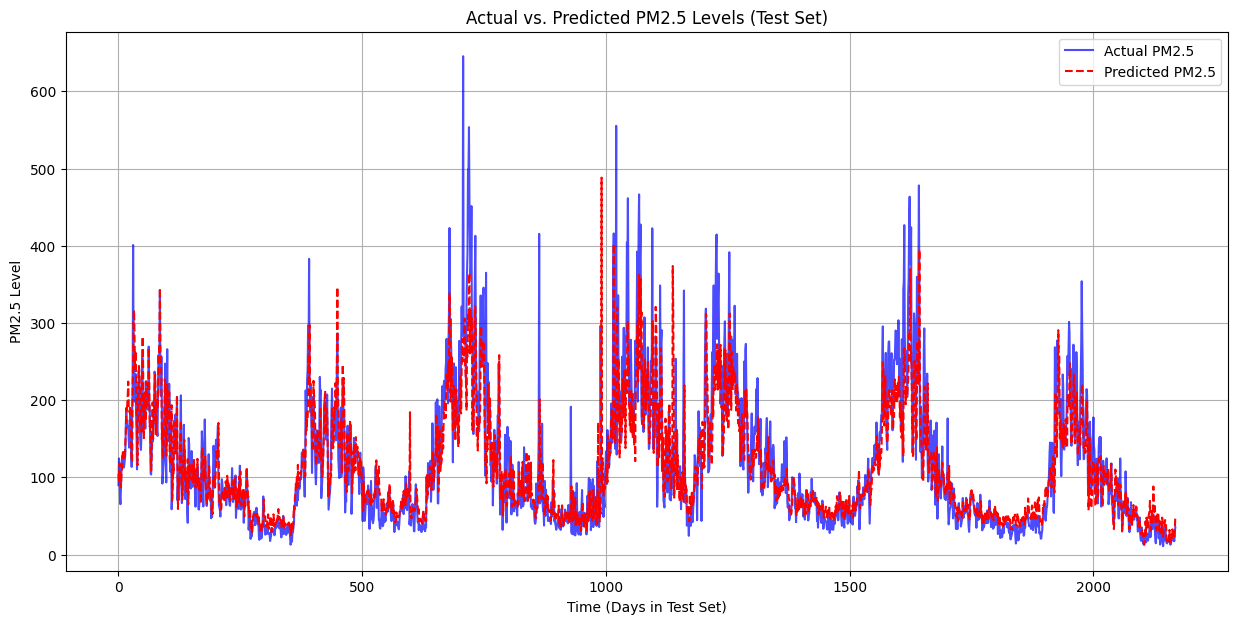

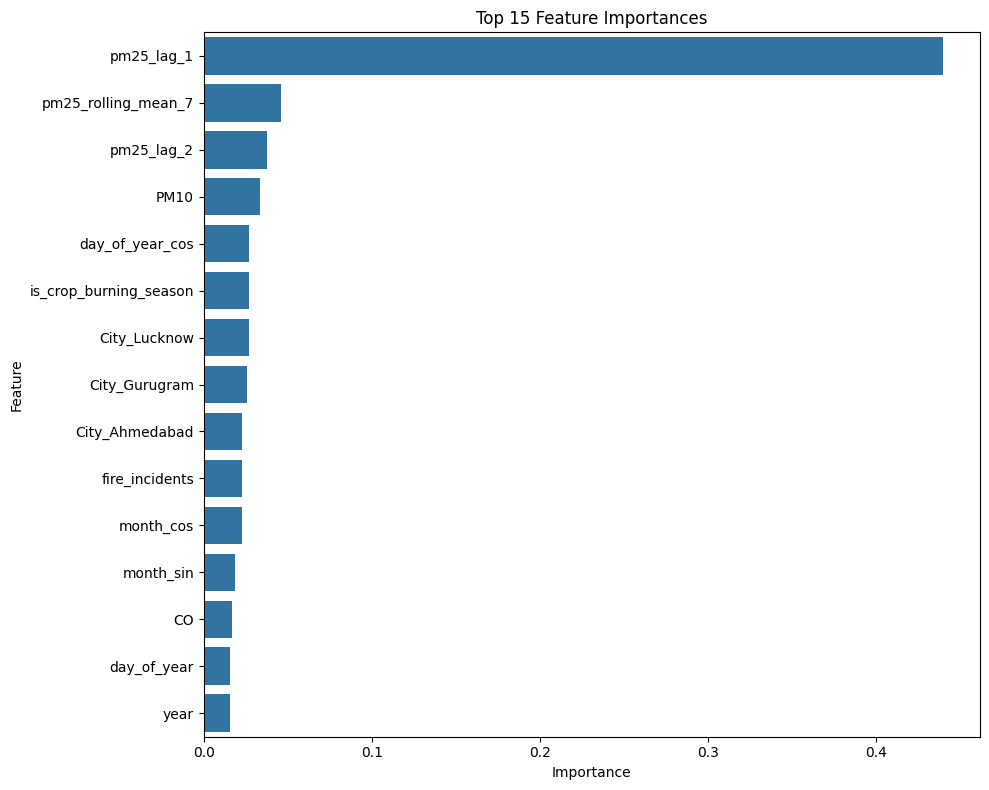

In [14]:
predictions = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Plot Predictions vs. Actuals
plt.figure(figsize=(15, 7))
plt.plot(y_test.values, label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(predictions, label='Predicted PM2.5', color='red', linestyle='--')
plt.title('Actual vs. Predicted PM2.5 Levels (Test Set)')
plt.xlabel('Time (Days in Test Set)')
plt.ylabel('PM2.5 Level')
plt.legend()
plt.grid(True)
plt.show()

# Plot Feature Importance
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = feature_importances.nlargest(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### More Visualizations and Factor Analysis

#### Correlation Heatmap
This shows which variables are most strongly correlated with PM2.5. Higher positive (closer to 1.0) or negative (closer to -1.0) values are more significant.

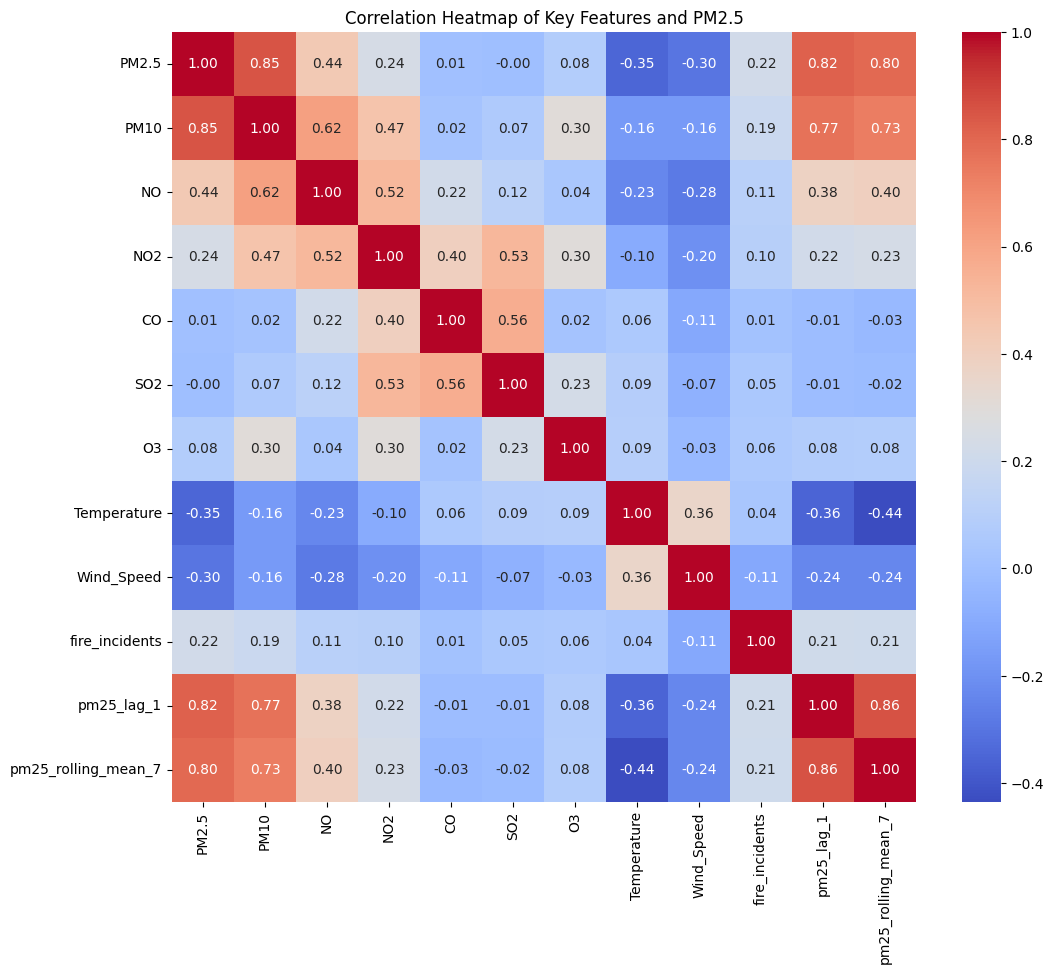

In [22]:
# Select the most important numerical features for the heatmap
heatmap_features = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'CO', 'SO2', 'O3',
    'Temperature', 'Wind_Speed', 'fire_incidents', 'pm25_lag_1', 'pm25_rolling_mean_7'
]

# Create a correlation matrix
corr_matrix = north_df[heatmap_features].corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Features and PM2.5')
plt.show()

#### Fire Incidents vs. PM2.5 Levels
This scatter plot directly visualizes the relationship between the daily count of stubble-burning fires in Punjab/Haryana and the PM2.5 levels in a major city like Delhi.

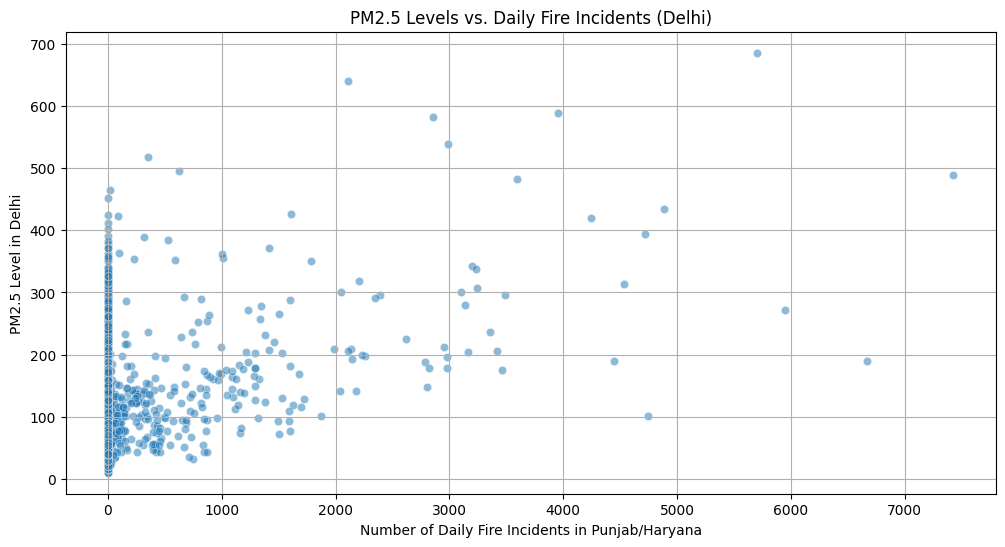

In [16]:
# Filter data for a specific city to see the impact clearly
delhi_df = north_df[north_df['City_Delhi'] == 1]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=delhi_df, x='fire_incidents', y='PM2.5', alpha=0.5)
plt.title('PM2.5 Levels vs. Daily Fire Incidents (Delhi)')
plt.xlabel('Number of Daily Fire Incidents in Punjab/Haryana')
plt.ylabel('PM2.5 Level in Delhi')
plt.grid(True)
plt.show()

# Model Download


In [21]:
import joblib

# Define a filename for your model
model_filename = 'xgb_northindia_aqi_cropfire_model.joblib'

# Save the best_model object to the specified file
joblib.dump(best_model, model_filename)

print(f"Model saved successfully as '{model_filename}'")
print("You can now download this file from the file pane on the left.")

Model saved successfully as 'xgb_northindia_aqi_cropfire_model.joblib'
You can now download this file from the file pane on the left.
